# Quickstart: ECMWF AIFS ENS forecast - dynamical.org Icechunk Zarr

ECMWF's Artificial Intelligence Forecasting System (AIFS) ENS is the ensemble configuration of the AI based AIFS weather forecast model. It produces 51-member global ensemble forecasts at 0.25° resolution, every 6 hours, out to 15 days in 6 hourly steps.

This dataset provides AIFS ENS forecasts from July 2025 to present, transformed into a single analysis-ready dataset by [dynamical.org](https://dynamical.org).

Dataset documentation: https://dynamical.org/catalog/ecmwf-aifs-ens-forecast/

Dataset licenced [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/) and [ECMWF Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy

In [2]:
import dynamical_catalog

ds = dynamical_catalog.open("ecmwf-aifs-ens-forecast", chunks=None)
ds

<xarray.Dataset> Size: 284TB
Dimensions:                                     (init_time: 1294,
                                                 lead_time: 61,
                                                 ensemble_member: 51,
                                                 latitude: 721, longitude: 1440)
Coordinates:
  * init_time                                   (init_time) datetime64[ns] 10kB ...
    expected_forecast_length                    (init_time) timedelta64[ns] 10kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 10kB ...
  * lead_time                                   (lead_time) timedelta64[ns] 488B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 631kB ...
  * ensemble_member                             (ensemble_member) int16 102B ...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
Data variables: (12/17)
    dew_point_temperature_2m                    (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    geopotential_height_500hpa                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    geopotential_height_850hpa                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    geopotential_height_925hpa                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    ...                                          ...
    temperature_925hpa                          (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    temperature_2m                              (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    wind_u_10m                                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    wind_u_100m                                 (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    wind_v_10m                                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
    wind_v_100m                                 (init_time, lead_time, ensemble_member, latitude, longitude) float32 17TB ...
Attributes:
    dataset_id:           ecmwf-aifs-ens-forecast
    dataset_version:      0.1.0
    name:                 ECMWF AIFS ENS forecast
    description:          Ensemble weather forecasts from the ECMWF Artificia...
    attribution:          ECMWF AIFS ENS forecast data processed by dynamical...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2025-07-02 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-360 hours (0-15 days) ahead
    forecast_resolution:  6 hourly

This is an ensemble forecast dataset with five dimensions: `init_time` (when the forecast run began), `lead_time` (how far ahead the forecast extends), `ensemble_member` (forecast "trace"), and `latitude` / `longitude`. The `valid_time` coordinate combines `init_time` and `lead_time` to give the actual forecasted time.

Each of the 51 members is one plausible future. Together they sample the range of outcomes the model considers possible for a given forecast. Let's start by visualizing all 51 members at a single point.

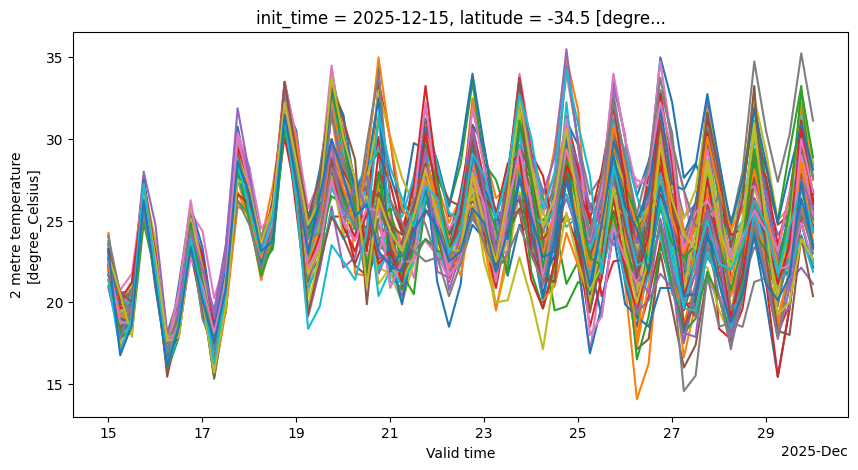

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 2 m temperature forecast for Buenos Aires in mid-summer.
plot_ds = ds.sel(init_time="2025-12-15T00", latitude=-34.61, longitude=-58.38, method="nearest")
_ = plot_ds["temperature_2m"].plot(x="valid_time", hue="ensemble_member", add_legend=False, figsize=(10, 5))

### Quantile bands

With 51 members it's often easier to read the ensemble as a distribution. Quantiles across `ensemble_member` give a compact summary of the forecast uncertainty.

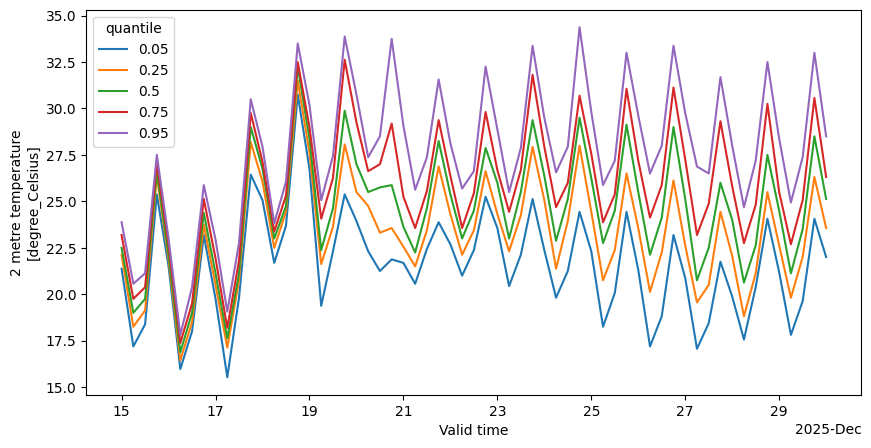

In [4]:
# Quantile summary of the ensemble distribution.
(
    ds["temperature_2m"]
    .sel(init_time="2025-12-15T00", latitude=-34.61, longitude=-58.38, method="nearest")
    .quantile([0.05, 0.25, 0.5, 0.75, 0.95], dim="ensemble_member")
    .plot(x="valid_time", hue="quantile", figsize=(10, 5))
)

### How likely was the polar vortex to drop the Midwest below -20 C?

A sudden stratospheric warming in early January 2026 brought a polar vortex disruption that pushed Arctic air into the central US around 22-26 January, breaking daily records in Nebraska, Michigan and Ohio. For each grid cell over the US Midwest and Plains, we can count how many of the 51 members predict the 10-day minimum `temperature_2m` to drop below -20 °C.

Text(0.5, 1.0, 'Polar vortex cold snap - probability of 10-day min temperature below -20 C\nAIFS ENS, init 2026-01-19 00Z')

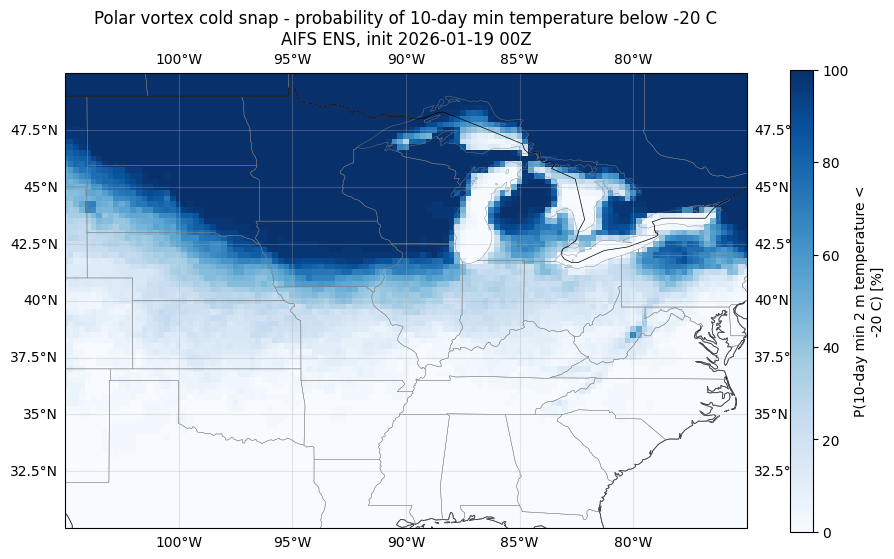

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Polar vortex cold-snap probability map
sub = ds["temperature_2m"].sel(
    init_time="2026-01-19T00",
    lead_time=slice("0h", "240h"),
    latitude=slice(50, 30),
    longitude=slice(-105, -75),
)
min_t = sub.min(dim="lead_time")
prob = (min_t < -20).mean(dim="ensemble_member") * 100
prob = prob.load()
prob.attrs["units"] = "%"
prob.attrs["long_name"] = "P(10-day min 2 m temperature < -20 C)"

fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()})
prob.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="Blues", vmin=0, vmax=100)
ax.coastlines(resolution="50m", color="black", linewidth=0.6)
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor="gray")
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="black")
ax.set_extent([-105, -75, 30, 50], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, alpha=0.3)
ax.set_title("Polar vortex cold snap - probability of 10-day min temperature below -20 C\nAIFS ENS, init 2026-01-19 00Z")

### How much rain will the Kona Low dump on Maui?

A slow-moving Kona Low parked over Hawaii from 10-16 March 2026, fed by an atmospheric river, and dropped 40+ inches of rain in parts of Maui. From an initialization a few days before the event, we can convert the 6-hourly `precipitation_surface` rate into a running cumulative total and ask: how much rain do the 51 members say will fall, and how widely do they disagree?

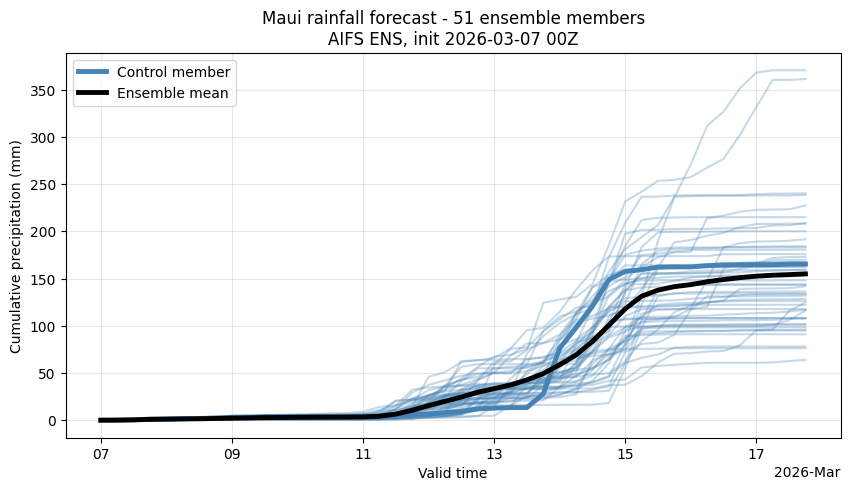

In [6]:
# Maui (Kahului area) cumulative rainfall over 10 days
rate = (
    ds["precipitation_surface"]
    .sel(init_time="2026-03-07T00", lead_time=slice("0h", "240h"))
    .sel(latitude=20.89, longitude=-156.47, method="nearest")
    .load()
)
step_s = float(rate.lead_time.diff("lead_time")[0] / np.timedelta64(1, "s"))
cumulative = (rate * step_s).cumsum("lead_time")

fig, ax = plt.subplots(figsize=(10, 5))
(
    cumulative.sel(ensemble_member=slice(1, 50))
    .plot(x="valid_time", hue="ensemble_member", ax=ax, alpha=0.3, color="steelblue", add_legend=False)
)
(
    cumulative.sel(ensemble_member=0)
    .plot(x="valid_time", ax=ax, color="steelblue", linewidth=3.5, label="Control member")
)
(
    cumulative.mean(dim="ensemble_member")
    .plot(x="valid_time", ax=ax, color="black", linewidth=3.5, label="Ensemble mean")
)
ax.set_ylabel("Cumulative precipitation (mm)")
ax.set_title("Maui rainfall forecast - 51 ensemble members\nAIFS ENS, init 2026-03-07 00Z")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

### How fast does forecast uncertainty grow?

A fundamental property of ensembles is that spread (disagreement between members) grows with lead time. We'd expect it to be near zero at hour 0, and to broaden out over the 15-day forecast. Let's plot ensemble standard deviation at a point as a function of lead time, across many recent winter initializations.

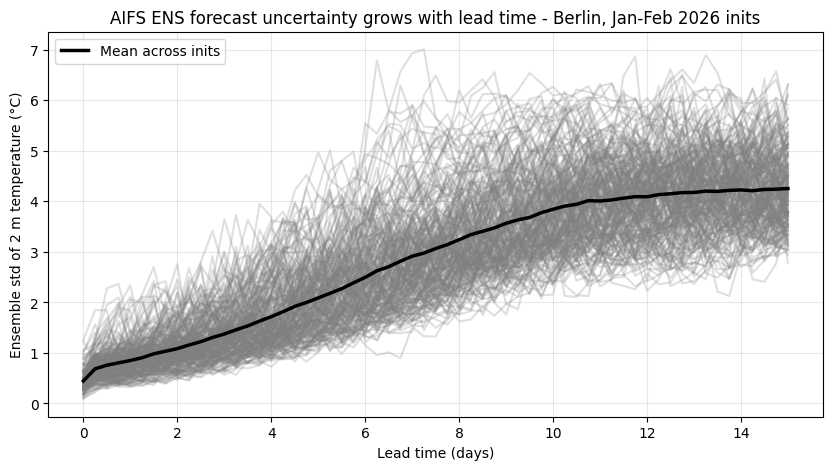

In [7]:
# Ensemble spread (standard deviation across ensemble members) of 2 m temperature at Berlin, for each Jan-Feb 2026 init
spread = (
    ds["temperature_2m"]
    .sel(latitude=52.52, longitude=13.40, method="nearest")
    .sel(init_time=slice("2026-01-01", "2026-02-28"))
    .std(dim="ensemble_member")
    .load()
)

lead_days = spread.lead_time / np.timedelta64(1, "D")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lead_days, spread.values.T, color="gray", alpha=0.25)
ax.plot(lead_days, spread.mean(dim="init_time").values, color="black", linewidth=2.5, label="Mean across inits")
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Ensemble std of 2 m temperature (°C)")
ax.set_title("AIFS ENS forecast uncertainty grows with lead time - Berlin, Jan-Feb 2026 inits")
ax.legend()
ax.grid(alpha=0.3)

### Animated: where does each member put Melissa's center?

Plotting all 51 member storm centers as a moving point cloud over the ensemble-mean mean sea level pressure (MSLP) field makes track uncertainty visible. Early in the forecast the cluster is tight; by day 5+, the members fan out across the Caribbean.

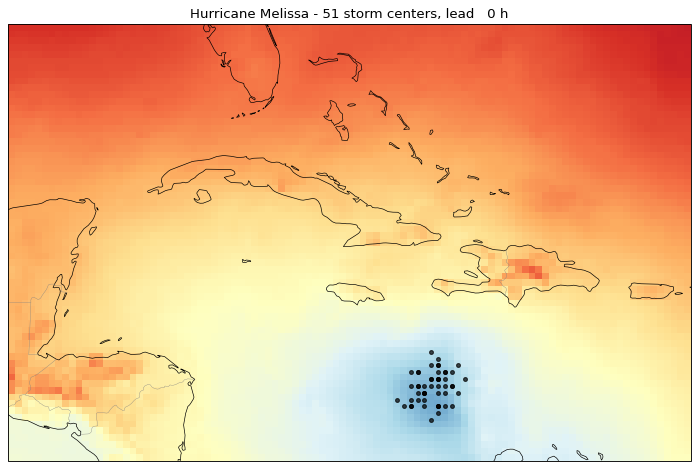

In [8]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def track_storm(mslp):
    """Per-(member, lead) MSLP-minimum lat/lon arrays."""
    stacked = mslp.stack(point=("latitude", "longitude"))
    idx = stacked.argmin("point")
    return stacked.latitude.values[idx.values], stacked.longitude.values[idx.values]


mslp = (
    ds["pressure_reduced_to_mean_sea_level"]
    .sel(init_time="2025-10-23T00", lead_time=slice("0h", "144h"))
    .sel(latitude=slice(28, 12), longitude=slice(-90, -65))
    .transpose("ensemble_member", "lead_time", "latitude", "longitude")
    .load()
)

track_lat, track_lon = track_storm(mslp)

mean_mslp = mslp.mean("ensemble_member")
lons = mean_mslp.longitude.values
lats = mean_mslp.latitude.values

fig, ax = plt.subplots(figsize=(9, 6), dpi=80, subplot_kw={"projection": ccrs.PlateCarree()})
fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.02)
ax.set_extent([lons[0], lons[-1], lats[-1], lats[0]], crs=ccrs.PlateCarree())
ax.coastlines(resolution="50m", color="black", linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="gray")
img = ax.imshow(
    mean_mslp.isel(lead_time=0).values,
    cmap="RdYlBu_r", vmin=float(mean_mslp.min()), vmax=float(mean_mslp.max()),
    extent=[lons[0], lons[-1], lats[-1], lats[0]], transform=ccrs.PlateCarree(),
)
scat = ax.scatter(track_lon[:, 0], track_lat[:, 0], color="black", s=12, alpha=0.7, transform=ccrs.PlateCarree())
title = ax.set_title("")

def update(frame_idx):
    img.set_data(mean_mslp.isel(lead_time=frame_idx).values)
    scat.set_offsets(np.column_stack([track_lon[:, frame_idx], track_lat[:, frame_idx]]))
    lead_h = int(mslp.lead_time[frame_idx].values / np.timedelta64(1, "h"))
    title.set_text(f"Hurricane Melissa - 51 storm centers, lead {lead_h:>3} h")
    return img, scat, title

anim = FuncAnimation(fig=fig, frames=mslp.sizes["lead_time"], func=update, interval=250)
HTML(anim.to_jshtml())

### Community challenge

AIFS ENS is a 51-member ensemble from an AI weather model — the same shape of dataset as ECMWF's physics-based IFS ENS and NOAA's GEFS, but powered by a fundamentally different model. That makes it especially rich for comparison work. A few ideas to spark exploration:

- **AIFS ENS vs IFS ENS spread.** Both are 51-member ensembles out to 15 days. For a major storm (a hurricane, a polar vortex outbreak, a European windstorm), compare the spread of `temperature_2m`, `wind_u_10m`/`wind_v_10m`, and `pressure_reduced_to_mean_sea_level` at matched valid times. How do the two models' dispersions compare?
- **AIFS ENS vs GEFS for cold snaps.** Cold extremes drive energy demand and grid stress. Pick a recent cold air outbreak, compute the probability of `temperature_2m` below a threshold for both ensembles, and compare. Which catches the event earlier? Which has more honest spread?
- **Renewable "Dunkelflaute" risk.** Combine wind power proxies (`|V|³` at 100 m for offshore wind regions) and solar (`downward_short_wave_radiation_flux_surface`) to compute ensemble probability of multi-day periods of compound low generation across Europe or Texas. How far ahead can the ensemble flag these high-stress windows for grid operators?